The goals in this notebook is to demonstrate a proof of concept of the entire Federated meta learning pipeline.  
The dataset that will be used is [MedMNST](https://medmnist.com/)

What we are trying to prove with this pipeline is can convergence be improved upon if the model has been trained on a vareity of tasks.   
This is turn may or may not help edge cases where the number of sample may be limited. Therefore, we use the following datasets in MedMNST as tasks.

[MedMNIST](https://medmnist.com/)
[RestNet18](https://pytorch.org/hub/pytorch_vision_resnet/)
- Requires that the images to be normalized. Link includes transformation
How to attach a head to a pre-trained Resnet
```python
import torch
import torch.nn as nn
import torchvision.models as models

# Load a pretrained ResNet model
resnet = models.resnet50(pretrained=True)

# Remove the last layer (fully connected layer)
modules = list(resnet.children())[:-1]
resnet_headless = nn.Sequential(*modules)

# Freeze parameters (optional)
for param in resnet_headless.parameters():
    param.requires_grad = False

# Example usage:
# Assuming you have an input image tensor called 'input_tensor'
# output = resnet_headless(input_tensor)
```
[Obtaining the Gradients](https://discuss.pytorch.org/t/get-the-gradient-of-the-network-parameters/50575)


In [1]:
# train_pneumonia_data = PneumoniaMNIST(root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_path_data      = PathMNIST     (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_chest_data     = ChestMNIST    (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_derma_data     = DermaMNIST    (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_oct_data       = OCTMNIST      (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_retina_data    = RetinaMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_breast_data    = BreastMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_blood_data     = BloodMNIST    (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_tissue_data    = TissueMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_organ_a_data   = OrganAMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_organ_c_data   = OrganCMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)
# train_organ_s_data   = OrganSMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="train", download=True)

# val_pneumonia_data = PneumoniaMNIST(root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_path_data      = PathMNIST     (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_chest_data     = ChestMNIST    (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_derma_data     = DermaMNIST    (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_oct_data       = OCTMNIST      (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_retina_data    = RetinaMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_breast_data    = BreastMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_blood_data     = BloodMNIST    (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_tissue_data    = TissueMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_organ_a_data   = OrganAMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_organ_c_data   = OrganCMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)
# val_organ_s_data   = OrganSMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="val", download=True)

# test_pneumonia_data = PneumoniaMNIST(root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_path_data      = PathMNIST     (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_chest_data     = ChestMNIST    (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_derma_data     = DermaMNIST    (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_oct_data       = OCTMNIST      (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_retina_data    = RetinaMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_breast_data    = BreastMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_blood_data     = BloodMNIST    (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_tissue_data    = TissueMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_organ_a_data   = OrganAMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_organ_c_data   = OrganCMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)
# test_organ_s_data   = OrganSMNIST   (root=data_folder, transform=preprocess, as_rgb = True, size=28, split="test", download=True)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets      import make_multilabel_classification
from sklearn.metrics       import classification_report
from sklearn.metrics       import label_ranking_loss
from sklearn.preprocessing import OneHotEncoder

from torchvision import models
from typing      import List
import copy

import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models
import torch.nn as nn
import torch

from IPython import display

import pandas as pd
from tqdm import tqdm
import numpy as np
import random
import os

torch.manual_seed(seed = 42)
random.seed(a = 42)

In [3]:
import psutil
(1 - psutil.virtual_memory().available / psutil.virtual_memory().total ) * 100

5.382128889560889

In [4]:
default_path = os.getcwd()
data_folder  = os.path.join(default_path,'Data')
if not os.path.isdir(data_folder):
    os.mkdir(data_folder)
data_folder

'/home/drew/FL-with-MIMIC/ScratchWork/Data'

In [5]:
preprocess = transforms.Compose([
    # transforms.ToPILImage(),
    transforms.Resize(256),
    transforms.Grayscale(num_output_channels=3),  # Ensure all images have 3 channels
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [6]:
from medmnist import (
    PathMNIST,       # Multi-Class (9)        | Colon Pathology | Train: 89,996 | Test: 7,180
    # ChestMNIST,      # Multi-Label (14), Binary-Class (2)     | Chest X-Ray | Train: 78,468 | Test: 22,433
    DermaMNIST,      # Multi-Class (7)        | Dermatoscope  | Train: 7,007 | Test: 2,005
    OCTMNIST,        # Multi-Class (4)        | Retinal OCT   | Train: 97,477 | Test: 1,000
    PneumoniaMNIST,  # Binary-Class (2)       | Chest X-Ray   | Train: 4,708 | Test: 624
    RetinaMNIST,     # Ordinal Regression (5) | Fundus Camera | Train: 1,080 | Test: 400
    BreastMNIST,     # Binary-Class (2)       | Breast Ultrasound            | Train: 546 | Test: 156
    BloodMNIST,      # Multi-Class (8)        | Blood Cell Microscope        | Train: 11,959 | Test: 3,421
    TissueMNIST,     # Multi-Class (8)        | Kidney Cortex Microscope     | Train: 165,466 | Test: 47,280
    OrganAMNIST,     # Multi-Class (11)       | Abdominal CT | Train: 34,561 | Test: 17,778
    OrganCMNIST,     # Multi-Class (11)       | Abdominal CT | Train: 12,975 | Test: 8,216
    OrganSMNIST      # Multi-Class (11)       | Abdominal CT | Train: 13,932 | Test: 8,827
)

In [7]:
medmnist_datasets = [PathMNIST  , 
                     #ChestMNIST, 
                     DermaMNIST , 
                     OCTMNIST   ,
                     # PneumoniaMNIST, 
                     RetinaMNIST,
                     BreastMNIST,
                     BloodMNIST ,
                     TissueMNIST, 
                     OrganAMNIST,
                     OrganCMNIST,
                     OrganSMNIST]

In [8]:
def data_loader(type, data_folder, preprocess, split):
    return type(root=data_folder, transform=preprocess, as_rgb = True, size=28, split=split, download=True)

In [8]:
training_tasks = [data_loader(t,data_folder,preprocess,split = 'train') for t in medmnist_datasets]
val_tasks      = [data_loader(t,data_folder,preprocess,split = 'val'  ) for t in medmnist_datasets]
test_tasks     = [data_loader(t,data_folder,preprocess,split = 'test' ) for t in medmnist_datasets]

training_tasks_loaders = [DataLoader(t, batch_size = 512 , shuffle = False) for t in training_tasks]
val_tasks_loaders      = [DataLoader(t, batch_size = 512 , shuffle = False) for t in val_tasks     ]
test_tasks_loaders     = [DataLoader(t, batch_size = 512 , shuffle = False) for t in test_tasks    ]

del training_tasks
del val_tasks
del test_tasks

---
Constructing the Resnet model for each task

In [22]:
task_output_dims = {
    'PathMNIST'     : 9,
    'ChestMNIST'    : 14,
    'DermaMNIST'    : 7,
    'OCTMNIST'      : 4,
    'PneumoniaMNIST': 2,
    'RetinaMNIST'   : 5,
    'BreastMNIST'   : 2,
    'BloodMNIST'    : 8,
    'TissueMNIST'   : 8,
    'OrganAMNIST'   : 11,
    'OrganCMNIST'   : 11,
    'OrganSMNIST'   : 11
}

def get_resnet_for_task(task_name, device='cpu'):
    model   = models.resnet18(weights=None)
    modules = list(model.children())[:-1]
    modules.append(nn.Flatten())
    modules.append(nn.Linear(512, task_output_dims[task_name]))
    return nn.Sequential(*modules).to(device)

def get_loss_fn(task_name):
    if task_name == 'ChestMNIST':
        return nn.BCEWithLogitsLoss()
    else:
        return nn.CrossEntropyLoss()

def load_backbone_weights(model, weights):
    model_state      = model.state_dict()
    filtered_weights = {k: v for k, v in weights.items() if k in model_state and v.shape == model_state[k].shape}
    model_state.update(filtered_weights)
    model.load_state_dict(model_state)

In [ ]:
class FederatedMAMLTrainer:
    def __init__(self, training_tasks, val_tasks, test_tasks, inner_lr=0.01, meta_lr=0.001, inner_steps=1, device="cpu"):
        self.training_tasks = training_tasks
        self.val_tasks      = val_tasks
        self.test_tasks     = test_tasks
        self.inner_lr       = inner_lr
        self.meta_lr        = meta_lr
        self.inner_steps    = inner_steps
        self.device         = device
        self.global_weights = None

    def inner_loop(self, task_loader):
        task_name = task_loader.dataset.__class__.__name__
        model = get_resnet_for_task(task_name, device=self.device)
        if self.global_weights:
            load_backbone_weights(model, self.global_weights)

        model.train()
        optimizer = torch.optim.SGD(model.parameters(), lr=self.inner_lr)
        loss_fn = get_loss_fn(task_name)

        for _ in range(self.inner_steps):
            for x, y in task_loader:
                x, y = x.to(self.device), y.to(self.device)
                if task_name == 'ChestMNIST':
                    y = y.float()
                elif isinstance(loss_fn, nn.CrossEntropyLoss):
                    y = y.long().squeeze()
                preds = model(x)
                loss = loss_fn(preds, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                break
        return model

    def aggregate_gradients(self, local_models: List[nn.Module], task_names: List[str]):
        base_task = task_names[0]
        global_model = get_resnet_for_task(base_task, device=self.device)
        if self.global_weights:
            load_backbone_weights(global_model, self.global_weights)

        for param in global_model.parameters():
            if param.requires_grad:
                param.grad = torch.zeros_like(param.data)

        for local_model in local_models:
            for g_param, l_param in zip(global_model.parameters(), local_model.parameters()):
                if g_param.shape == l_param.shape and l_param.grad is not None:
                    g_param.grad += l_param.grad

        for param in global_model.parameters():
            if param.grad is not None:
                param.grad /= len(local_models)

        optimizer = torch.optim.SGD(global_model.parameters(), lr=self.meta_lr)
        optimizer.step()
        self.global_weights = copy.deepcopy(global_model.state_dict())

    def train(self, meta_epochs=2, num_clients_per_round=3):
        first_task_name = self.training_tasks[0].dataset.__class__.__name__
        model = get_resnet_for_task(first_task_name, device=self.device)
        self.global_weights = copy.deepcopy(model.state_dict())

        for epoch in range(meta_epochs):
            sampled_tasks = random.sample(self.training_tasks, num_clients_per_round)
            local_models = []
            task_names = []

            for task_loader in sampled_tasks:
                task_name = task_loader.dataset.__class__.__name__
                model = self.inner_loop(task_loader)
                model.zero_grad()
                loss_fn = get_loss_fn(task_name)

                for x, y in task_loader:
                    x, y = x.to(self.device), y.to(self.device)
                    if task_name == 'ChestMNIST':
                        y = y.float()
                    elif isinstance(loss_fn, nn.CrossEntropyLoss):
                        y = y.long().squeeze()
                    preds = model(x)
                    loss = loss_fn(preds, y)
                    loss.backward()
                    break

                local_models.append(model)
                task_names.append(task_name)

            self.aggregate_gradients(local_models, task_names)
            print(f"Meta Epoch {epoch+1}/{meta_epochs} complete.")

    def evaluate(self, task_loaders):
            results = []
            for task_loader in tqdm(task_loaders):
                task_name = task_loader.dataset.__class__.__name__
                model = get_resnet_for_task(task_name)
                model = model.to(self.device)
                load_backbone_weights(model, self.global_weights)
                model.eval()

                correct, total = 0, 0
                with torch.no_grad():
                    for x, y in task_loader:
                        x = x.to(self.device, non_blocking=True)
                        y = y.to(self.device, non_blocking=True)
                        outputs = model(x)
                        if task_name == 'ChestMNIST':
                            preds = torch.round(torch.sigmoid(outputs))
                            correct += (preds == y).sum().item()
                            total   += y.numel()
                        else:
                            preds = torch.argmax(outputs, dim=1)
                            correct += (preds.flatten() == y.flatten()).long().sum().item()
                            total += y.size(0)
                acc = correct / total
                results.append(acc)
            return results


In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [26]:
# Instantiate and run the trainer
trainer = FederatedMAMLTrainer(
    training_tasks = training_tasks_loaders,
    val_tasks      = val_tasks_loaders,
    test_tasks     = test_tasks_loaders,
    inner_lr       = 0.01,
    meta_lr        = 0.001,
    inner_steps    = 1,
    device         = device
)

print('Training...')
trainer.train(meta_epochs=2, num_clients_per_round=3)

Training...
Meta Epoch 1/2 complete.
Meta Epoch 2/2 complete.


In [27]:
print('Validating...')
val_results = trainer.evaluate(val_tasks_loaders)

Validating...
PathMNIST
DermaMNIST
OCTMNIST
PneumoniaMNIST
RetinaMNIST
BreastMNIST
BloodMNIST
TissueMNIST
OrganAMNIST
OrganCMNIST
OrganSMNIST


In [28]:
print('Testing...')
test_results = trainer.evaluate(test_tasks_loaders)

Testing...
PathMNIST
DermaMNIST
OCTMNIST
PneumoniaMNIST
RetinaMNIST
BreastMNIST
BloodMNIST
TissueMNIST
OrganAMNIST
OrganCMNIST
OrganSMNIST


In [29]:
# Display results
dataframe=pd.DataFrame({
    "Task"         : [t.__name__ for t in medmnist_datasets],
    "Val Accuracy" : val_results,
    "Test Accuracy": test_results
})
dataframe

,Task,Val Accuracy,Test Accuracy
0,PathMNIST,0.113655,0.103203
1,DermaMNIST,0.110668,0.014464
2,OCTMNIST,0.343519,0.250000
3,PneumoniaMNIST,0.742366,0.625000
4,RetinaMNIST,0.075000,0.050000
5,BreastMNIST,0.269231,0.730769
6,BloodMNIST,0.071262,0.104355
7,TissueMNIST,0.071235,0.046574
8,OrganAMNIST,0.078724,0.059399
9,OrganCMNIST,0.021321,0.038948


---

# Centralized

In [9]:
def evaluate_model(model, data_loader, device = torch.device('cpu')):
    model.eval()
    model.to(device)
    total_correct, total = 0,0
    for data_input, data_label in (data_loader):
        data_input = data_input.to(device)
        data_label = data_label.to(device)
        preds      = model(data_input)
        # preds      = torch.argmax(preds,dim = 1)
        preds     = (preds >= 0.5).long(); preds = preds.flatten()
        total     += data_label.shape[0]
        total_correct += (preds == data_label.flatten()).long().sum().item()
    #print(total_correct,total)
    # print(f'Acc: {total_correct/total}')
    return total_correct/total


In [10]:
# device = torch.device('cpu')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
train_set = PneumoniaMNIST(root='Data', transform=preprocess, as_rgb = True, size=28, split='train', download=True)
val_set   = PneumoniaMNIST(root='Data', transform=preprocess, as_rgb = True, size=28, split='val'  , download=True)
test_set  = PneumoniaMNIST(root='Data', transform=preprocess, as_rgb = True, size=28, split='test' , download=True)

train_loader = DataLoader(train_set, batch_size = 128 , shuffle = False)
val_loader   = DataLoader(val_set  , batch_size = 128 , shuffle = False)
test_loader  = DataLoader(test_set , batch_size = 128 , shuffle = False)

In [12]:
model   = models.resnet18(weights=None)
modules = list(model.children())[:-1]
modules.append(nn.Flatten())
modules.append(nn.Dropout(0.5))
modules.append(nn.Linear(512, 1))
model   = nn.Sequential(*modules)

In [13]:
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas = (0.9,0.999))
# loss_fn   = nn.CrossEntropyLoss()
loss_fn = nn.BCEWithLogitsLoss()

In [14]:
# Training Routine
history = []
model.train()
for epoch in tqdm(range(20)):
    for data_input, data_label in train_loader:
        data_input = data_input.to(device)
        data_label = data_label.to(device)
        preds      = model(data_input)
        loss = loss_fn(preds, data_label.type(torch.float))
        history.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

100%|██████████| 20/20 [03:16<00:00,  9.81s/it]


In [15]:
print(evaluate_model(model,train_loader,device))
print(evaluate_model(model,val_loader,device))
print(evaluate_model(model,test_loader,device))

0.9836448598130841
0.9446564885496184
0.8717948717948718


740


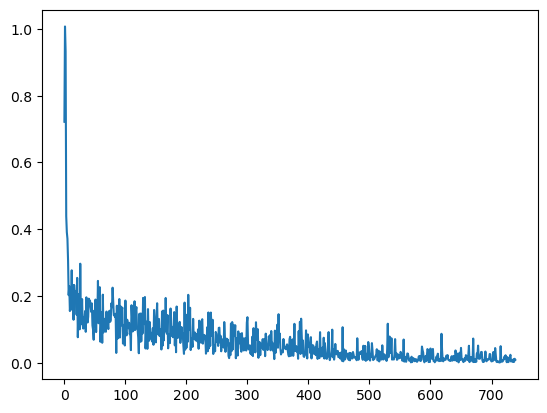

In [16]:
print(len(history))
plt.plot(history)
plt.show()

---

# Metal Learning

I'm going to try converting the multi-class into a series of binary classifcation to simplify the head shape. (512,1)

In [87]:
gray_scale = transforms.Grayscale(num_output_channels=3)

In [114]:
def data_loader(type, data_folder, preprocess, split):
    return type(root= data_folder, transform = preprocess, as_rgb = False, size=28, split=split, download=True)

def generate_tasks(dataset):
    n_classes = int(max(np.unique(dataset.labels)))
    all_tasks = []
    for task in range(n_classes):
        l_task = task; r_task = task + 1
        l_idxs = np.where(dataset.labels == l_task)[0]
        r_idxs = np.where(dataset.labels == r_task)[0]
        images = np.concatenate((dataset.imgs[l_idxs], dataset.imgs[r_idxs]), axis = 0)
        if images.shape[-1] == 3:
            images = images.reshape(len(images),3,28,28)
        else:
            # images = np.expand_dims(images, axis = 1)
            images = np.stack((images,images,images),axis=1)
            print(images.shape)
        # print(images.shape)
        labels = np.concatenate((np.zeros(shape = dataset.labels[l_idxs].shape), np.ones(shape = dataset.labels[r_idxs].shape)), axis = 0)
        all_tasks.append((images,labels))
    return all_tasks


def all_tasks(split = 'train', medmnist_datasets = None):
    training_tasks = []
    for t in medmnist_datasets:
        print(t.__name__)
        D = data_loader(t,data_folder,preprocess,split = split)
        
        training_tasks.extend(generate_tasks(D))
    return training_tasks


medmnist_datasets = [PathMNIST,DermaMNIST,OCTMNIST,RetinaMNIST,BreastMNIST,BloodMNIST,TissueMNIST,OrganAMNIST,OrganCMNIST,OrganSMNIST]

tasks = all_tasks('train',medmnist_datasets)
t = [(torch.Tensor(imgs),torch.Tensor(labels)) for imgs,labels in tasks]
ts = [DataLoader(TensorDataset(imgs,labels), batch_size = 512 , shuffle = True) for imgs,labels in t]

PathMNIST
DermaMNIST
OCTMNIST
(43697, 3, 28, 28)
(17967, 3, 28, 28)
(53780, 3, 28, 28)
RetinaMNIST
BreastMNIST
(546, 3, 28, 28)
BloodMNIST
TissueMNIST
(60889, 3, 28, 28)
(13680, 3, 28, 28)
(21272, 3, 28, 28)
(27195, 3, 28, 28)
(19494, 3, 28, 28)
(46908, 3, 28, 28)
(63811, 3, 28, 28)
OrganAMNIST
(3346, 3, 28, 28)
(2747, 3, 28, 28)
(2831, 3, 28, 28)
(5437, 3, 28, 28)
(7780, 3, 28, 28)
(9981, 3, 28, 28)
(10083, 3, 28, 28)
(7848, 3, 28, 28)
(6960, 3, 28, 28)
(6592, 3, 28, 28)
OrganCMNIST
(1767, 3, 28, 28)
(1214, 3, 28, 28)
(1195, 3, 28, 28)
(1688, 3, 28, 28)
(2258, 3, 28, 28)
(4156, 3, 28, 28)
(3988, 3, 28, 28)
(2024, 3, 28, 28)
(2195, 3, 28, 28)
(2745, 3, 28, 28)
OrganSMNIST
(1778, 3, 28, 28)
(1244, 3, 28, 28)
(1335, 3, 28, 28)
(1853, 3, 28, 28)
(2251, 3, 28, 28)
(4583, 3, 28, 28)
(4205, 3, 28, 28)
(1544, 3, 28, 28)
(2807, 3, 28, 28)
(3560, 3, 28, 28)


In [115]:
model   = models.resnet18(weights=None)
modules = list(model.children())[:-1]
modules.append(nn.Flatten())
modules.append(nn.Dropout(0.5))
modules.append(nn.Linear(512, 1))
model   = nn.Sequential(*modules)

In [116]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')

Device: cuda


In [ ]:
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas = (0.9,0.999))
loss_fn   = nn.BCEWithLogitsLoss()

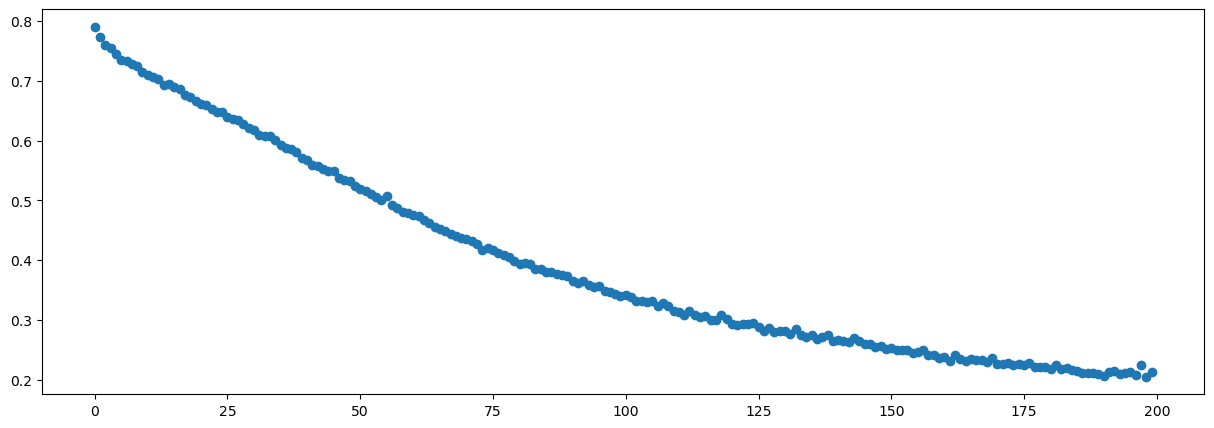

In [118]:
history = []
for rounds in (range(200)):
    print(f'Round: {rounds}')
    optimizer.zero_grad()
    total_loss = 0
    count      = 0
    for task in tqdm(ts):
        # We randomly pick the first task
        sampled = False
        for data_inputs, data_labels in task:
            if not sampled:
                data_inputs = data_inputs.to(device)
                data_labels = data_labels.to(device)
                preds    = model(data_inputs)
                loss     = loss_fn(preds, data_labels)

                loss.backward()
                total_loss += loss.item()
                count += 1
                sampled = True
    history.append(total_loss / count)
    optimizer.step()
    display.clear_output(wait=True)
    plt.figure(figsize=(15,5))
    plt.scatter([i for i, _ in enumerate(history)],history)
    plt.show()

In [119]:
torch.save(model.state_dict(),'Data/MAML_Central.tar')

In [120]:
train_set = PneumoniaMNIST(root='Data', transform=preprocess, as_rgb = True, size=28, split='train', download=True)
val_set   = PneumoniaMNIST(root='Data', transform=preprocess, as_rgb = True, size=28, split='val'  , download=True)
test_set  = PneumoniaMNIST(root='Data', transform=preprocess, as_rgb = True, size=28, split='test' , download=True)

train_loader = DataLoader(train_set, batch_size = 128 , shuffle = False)
val_loader   = DataLoader(val_set  , batch_size = 128 , shuffle = False)
test_loader  = DataLoader(test_set , batch_size = 128 , shuffle = False)

In [174]:
model   = models.resnet18(weights=None)
modules = list(model.children())[:-1]
modules.append(nn.Flatten())
modules.append(nn.Dropout(0.5))
modules.append(nn.Linear(512, 1))
model   = nn.Sequential(*modules)

weights = torch.load('Data/MAML_Central.tar')

model_state = model.state_dict()
filtered_weights = {k: v for k, v in weights.items() if k in model_state and v.shape == model_state[k].shape}
model_state.update(filtered_weights)
model.load_state_dict(model_state)

<All keys matched successfully>

In [175]:
# device = torch.device('cpu')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [176]:
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas = (0.9,0.999))
loss_fn   = nn.BCEWithLogitsLoss()

history = []
val_acc = []
curr_acc = 0
for epoch in tqdm(range(10)):
    for data_input, data_label in train_loader:
        data_input = data_input.to(device)
        data_label = data_label.to(device)
        preds      = model(data_input)
        loss = loss_fn(preds, data_label.type(torch.float))
        history.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    val_acc.append(evaluate_model(model,val_loader,device))

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:28<00:00,  8.83s/it]


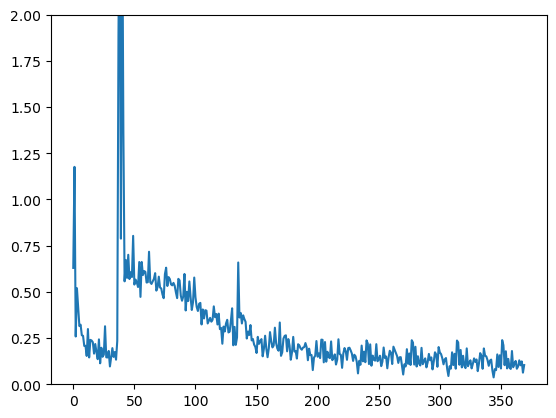

In [177]:
plt.plot(history)
plt.ylim((0,2))
plt.show()

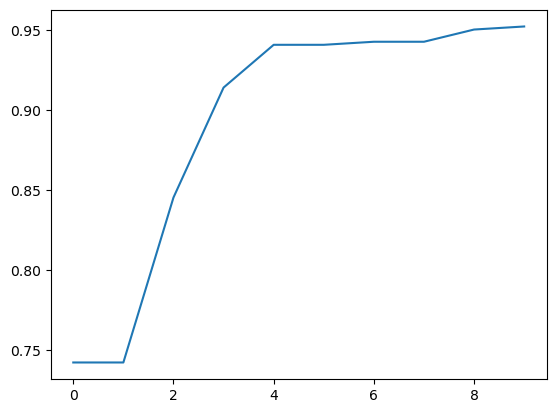

In [178]:
plt.plot(val_acc)
plt.show()

In [179]:
print(evaluate_model(model,train_loader ,device))
print(evaluate_model(model,val_loader   ,device))
print(evaluate_model(model,test_loader  ,device))

0.9590059473237044
0.9522900763358778
0.8365384615384616
